# Start-date sensitivity — account survival and exit-policy dependence

This appendix reruns five execution strategies from five monthly account starts.
The main framework showcase remains a comparison of different strategies over a
common period. Here the question is whether the outcome depends on account inception.

Each restart uses £50,000, frozen saved forecasts/signals and the same costs. The
engine starts with no earlier positions or unsettled PnL. This is retrospective
research, not selection of a more flattering start date.


In [1]:
%matplotlib inline
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))
from scripts.run_start_date_study import run_study

figures = {}
report = run_study(ROOT, figures=figures)
results = pd.DataFrame(report["results"])
print("Equal forecast-coverage window:", report["equal_calendar_days"], "calendar days")
print("Common-price date-coverage check:", report["strict_common_price_calendar_days"], "calendar days")
display(pd.DataFrame(report["windows"]))


No event loop hook running.
Equal forecast-coverage window: 20 calendar days
Common-price date-coverage check: 7 calendar days


,requested_start,actual_start,contiguous_days_up_to_cap,equal_end_exclusive
0,2018-07-01,2018-07-23T00:00:00+01:00,30,2018-08-12T00:00:00+01:00
1,2018-08-01,2018-08-01T00:00:00+01:00,30,2018-08-21T00:00:00+01:00
2,2018-09-01,2018-09-01T00:00:00+01:00,30,2018-09-21T00:00:00+01:00
3,2018-10-01,2018-10-01T00:00:00+01:00,20,2018-10-21T00:00:00+01:00
4,2018-11-01,2018-11-02T00:00:00+00:00,30,2018-11-22T00:00:00+00:00


## Equal-length windows

The primary comparison uses 20 calendar days, determined by the available forecast
dates rather than PnL. November has incomplete common-price coverage and is marked †.
The companion seven-day window has a common-price observation on each calendar date
for every start; neither date-coverage measure guarantees observations in every
half-hour. Short-window Sharpe is descriptive.

All strategies share the same price exclusions. “Terminal below floor” flags a
loss that may only become observable for a halt after the chosen window ends.


equal_window
strict_price_window


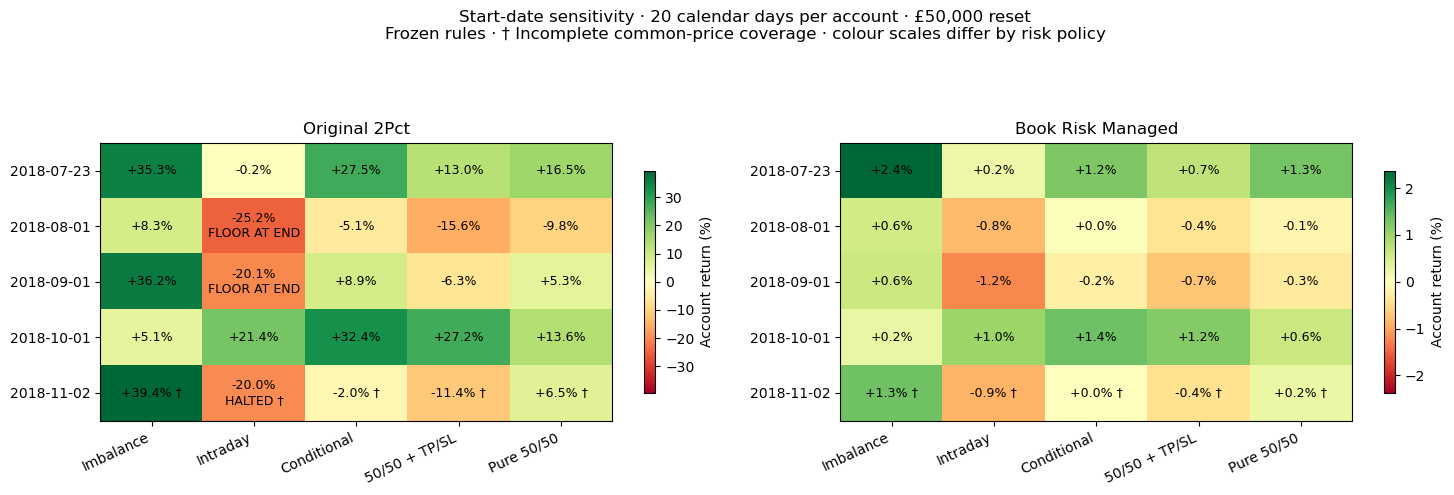

actual_start,risk_policy,strategy,calendar_days,common_price_days,return_pct,max_drawdown_pct,halted,terminal_below_floor
2018-07-23,original_2pct,Full imbalance,20,20,+35.3%,8.5%,False,False
2018-07-23,original_2pct,Systematic intraday unwind,20,20,-0.2%,6.8%,False,False
2018-07-23,original_2pct,Conditional TP/SL,20,20,+27.5%,6.5%,False,False
2018-07-23,original_2pct,50/50 with TP/SL,20,20,+13.0%,5.3%,False,False
2018-07-23,original_2pct,Pure 50/50 hedge,20,20,+16.5%,6.0%,False,False
2018-07-23,book_risk_managed,Full imbalance,20,20,+2.4%,0.5%,False,False
2018-07-23,book_risk_managed,Systematic intraday unwind,20,20,+0.2%,0.3%,False,False
2018-07-23,book_risk_managed,Conditional TP/SL,20,20,+1.2%,0.4%,False,False
2018-07-23,book_risk_managed,50/50 with TP/SL,20,20,+0.7%,0.3%,False,False
2018-07-23,book_risk_managed,Pure 50/50 hedge,20,20,+1.3%,0.4%,False,False


actual_start,risk_policy,strategy,calendar_days,common_price_days,return_pct,max_drawdown_pct,halted,terminal_below_floor
2018-07-23,original_2pct,Full imbalance,7,7,+11.2%,5.2%,False,False
2018-07-23,original_2pct,Systematic intraday unwind,7,7,-1.0%,3.6%,False,False
2018-07-23,original_2pct,Conditional TP/SL,7,7,+5.6%,4.8%,False,False
2018-07-23,original_2pct,50/50 with TP/SL,7,7,+2.3%,3.1%,False,False
2018-07-23,original_2pct,Pure 50/50 hedge,7,7,+5.0%,3.4%,False,False
2018-07-23,book_risk_managed,Full imbalance,7,7,+1.2%,0.5%,False,False
2018-07-23,book_risk_managed,Systematic intraday unwind,7,7,+0.1%,0.3%,False,False
2018-07-23,book_risk_managed,Conditional TP/SL,7,7,+0.3%,0.4%,False,False
2018-07-23,book_risk_managed,50/50 with TP/SL,7,7,+0.2%,0.3%,False,False
2018-07-23,book_risk_managed,Pure 50/50 hedge,7,7,+0.6%,0.4%,False,False


In [2]:
display(figures["equal_windows"])
for mode in ("equal_window", "strict_price_window"):
    print(mode)
    cols = ["actual_start", "risk_policy", "strategy", "calendar_days", "common_price_days",
            "return_pct", "max_drawdown_pct", "halted", "terminal_below_floor"]
    display(results.loc[results["mode"].eq(mode), cols].style.format({
        "return_pct": "{:+.1f}%", "max_drawdown_pct": "{:.1f}%"
    }).hide(axis="index"))


## Every start through December

These paths have different durations. They illustrate survival, not an endpoint
ranking. The grey interval has no saved forecasts; the replay is idle there.
Earlier starts experience August's loss and later ones do not. The restart changes
position sizes and subsequent capital-halt decisions, so it is not a vertical shift
of the original equity curve.


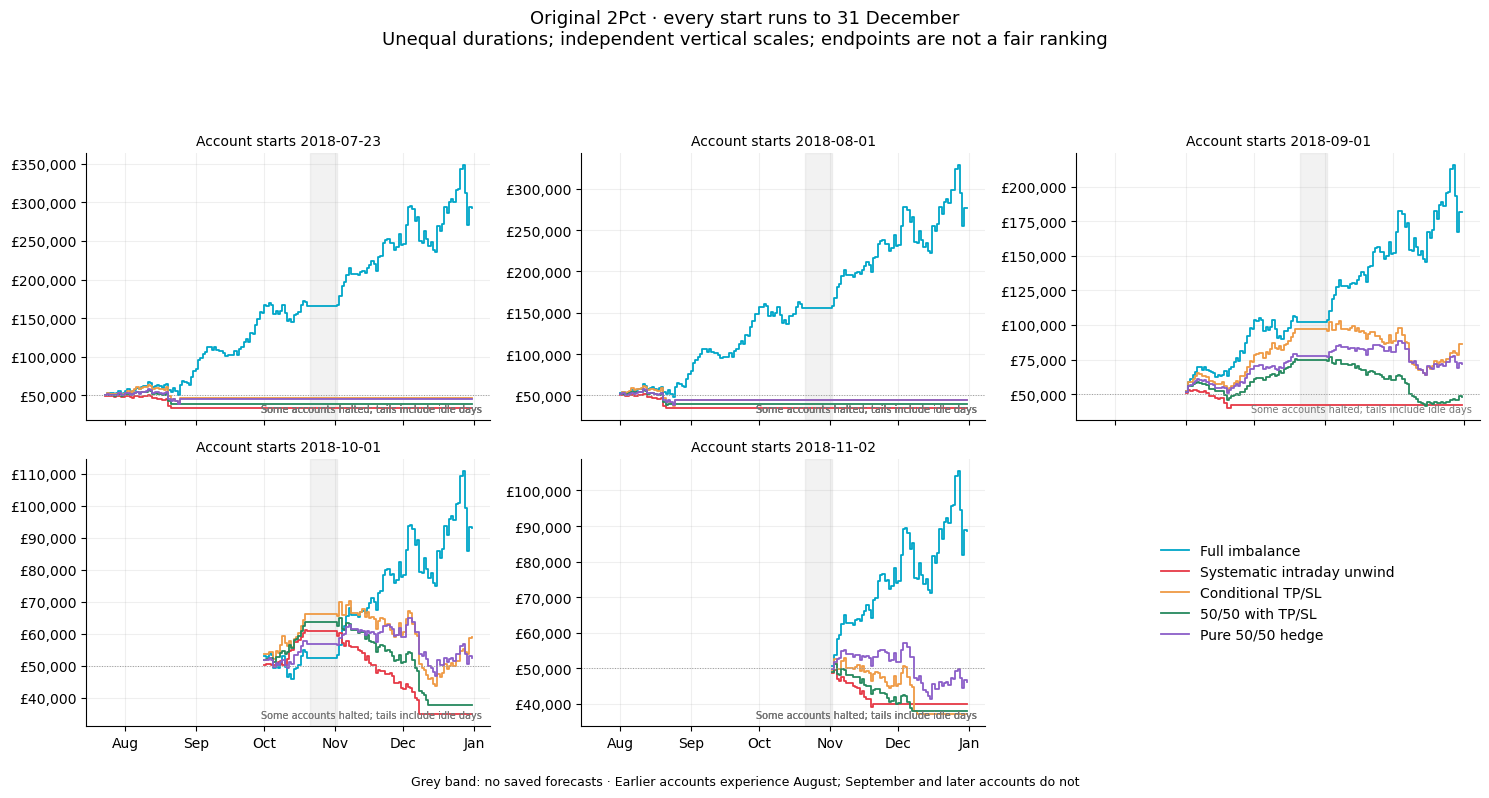

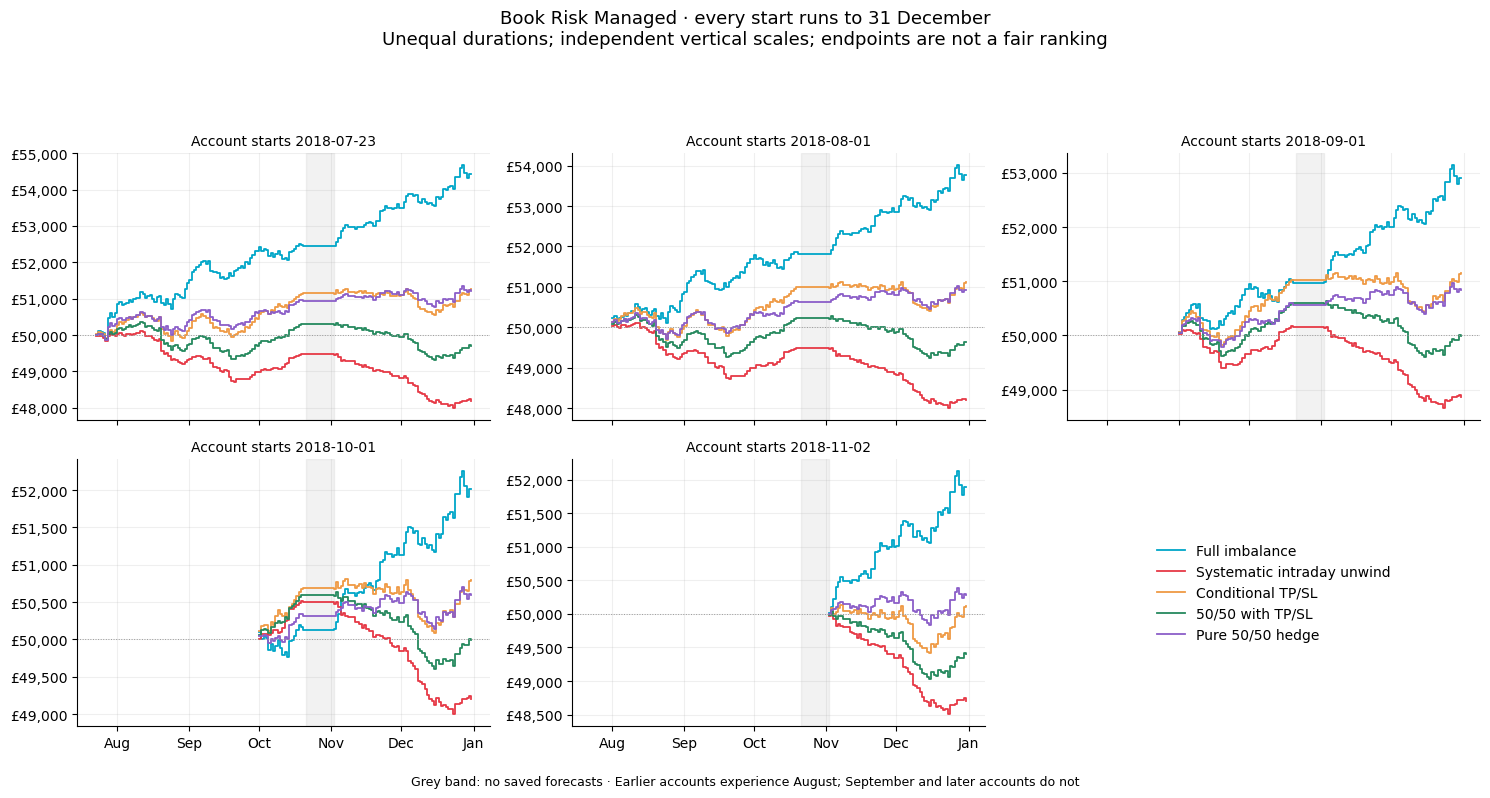

actual_start,risk_policy,strategy,calendar_days,forecast_days,common_price_days,net_pnl,return_pct,halted,terminal_below_floor
2018-07-23,original_2pct,Full imbalance,162,150,148,"£242,931",+485.9%,False,False
2018-07-23,original_2pct,Systematic intraday unwind,162,150,148,"£-16,480",-33.0%,True,True
2018-07-23,original_2pct,Conditional TP/SL,162,150,148,"£-3,920",-7.8%,True,False
2018-07-23,original_2pct,50/50 with TP/SL,162,150,148,"£-10,826",-21.7%,True,True
2018-07-23,original_2pct,Pure 50/50 hedge,162,150,148,"£-5,411",-10.8%,True,False
2018-07-23,book_risk_managed,Full imbalance,162,150,148,"£4,420",+8.8%,False,False
2018-07-23,book_risk_managed,Systematic intraday unwind,162,150,148,"£-1,806",-3.6%,False,False
2018-07-23,book_risk_managed,Conditional TP/SL,162,150,148,"£1,257",+2.5%,False,False
2018-07-23,book_risk_managed,50/50 with TP/SL,162,150,148,£-297,-0.6%,False,False
2018-07-23,book_risk_managed,Pure 50/50 hedge,162,150,148,"£1,218",+2.4%,False,False


In [3]:
for name in ("original_2pct", "book_risk_managed"):
    display(figures[name])
cols = ["actual_start", "risk_policy", "strategy", "calendar_days", "forecast_days",
        "common_price_days", "net_pnl", "return_pct", "halted", "terminal_below_floor"]
display(results.loc[results["mode"].eq("to_year_end"), cols].style.format({
    "net_pnl": "£{:,.0f}", "return_pct": "{:+.1f}%"
}).hide(axis="index"))


## Interpretation

September avoids the August loss, but systematic intraday unwind still halts later
at the original sizing. The conditional and pure 50/50 strategies finish that
replay profitably; the 50/50 TP/SL overlay survives with a loss. With the common
book-risk policy, every strategy survives from each tested start.

October's equal-length window favours conditional execution over full imbalance;
September favours full imbalance. That motivates testing a prospective regime or
remaining-edge rule. It does not establish a preferred start or a hedge that always
wins. The experiment measures path dependence while retaining every tested result.
